In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from wordcloud import WordCloud

Import reddit data as a .jsonl file, transform into a csv/data frame for ease of use

In [3]:
# load json file as a csv
import pandas as pd
import json
import os

filename = '/content/drive/MyDrive/Colab Notebooks/INFO 440/Final Project/r_Drexel_posts.jsonl'  #json lines file, subreddit creation - 07/01/2026
output_folder = '/content/drive/MyDrive/Colab Notebooks/INFO 440/Final Project'

with open(filename) as f:
    lines = f.read().splitlines()

my_dict = {}
for i, line in enumerate(lines):
    try:
        my_dict[i] = json.loads(line)
    except:
        pass

df_raw = pd.DataFrame.from_dict(my_dict).T

df_raw.to_csv('/content/drive/MyDrive/Colab Notebooks/INFO 440/Final Project/r_Drexel_posts_raw.csv') # export of raw data
df_raw.shape


(32053, 134)

In [4]:
df_raw.head()

,archived,author,author_flair_background_color,author_flair_css_class,author_flair_richtext,author_flair_text,author_flair_text_color,author_flair_type,brand_safe,can_gild,...,is_gallery,call_to_action,author_is_blocked,_meta,previous_selftext,location_lat,location_long,location_name,websocket_url,outbound_link
0,True,brtw,None,textflair,"[{'e': 'text', 't': 'Alumni | Cheese'}]",Alumni | Cheese,None,richtext,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,brtw,None,textflair,"[{'e': 'text', 't': 'Alumni | Cheese'}]",Alumni | Cheese,None,richtext,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,True,[deleted],,None,NaN,None,dark,NaN,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,True,Sporknight,None,None,[],None,None,text,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,True,kjhobin,None,textflair,"[{'e': 'text', 't': 'Information Systems Alum ...",Information Systems Alum '13,None,richtext,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# basic dataset analysis

# listing all the columns
print(df_raw.columns)

# checking for missing values
df_raw.isnull().sum().sort_values(ascending=False)

Index(['archived', 'author', 'author_flair_background_color',
       'author_flair_css_class', 'author_flair_richtext', 'author_flair_text',
       'author_flair_text_color', 'author_flair_type', 'brand_safe',
       'can_gild',
       ...
       'is_gallery', 'call_to_action', 'author_is_blocked', '_meta',
       'previous_selftext', 'location_lat', 'location_long', 'location_name',
       'websocket_url', 'outbound_link'],
      dtype='object', length=134)


,0
post_categories,32053
location_lat,32053
suggested_sort,32053
likes,32053
banned_by,32053
...,...
created_utc,0
num_comments,0
media_embed,0
over_18,0


From a the above excerpt of the dataset, we can see rows that contain information about posts and authors that have been reomved or deleted. We will start by filtering these out.

We also see that the dataset has 134 columns and a lot of these are not very useful for our goal of performing sentiment analysis on this dataset. They also have a lot of missing values, since this all the metadata that the Reddit API pulled. Therefore, in the next steps, we will get rid of most of these columns while retaining columns like id, author, created_utc, title, and selftext as we think that these are the columns most important for our analysis.

In [6]:
# remove deleted, removed posts
df_raw = df_raw[~df_raw["author"].isin(["[removed]", "[deleted]", ""])]
df_raw = df_raw[~df_raw["selftext"].isin(["[removed]", "[deleted]", ""])]

# keep only relavent columns
df_filtered = df_raw[["id", "author", "created_utc", "title", "selftext"]]

print(df_filtered.shape)
print()
df_filtered.head()


(22132, 5)



,id,author,created_utc,title,selftext
9,cf46u,tins1,1276584991,Incoming Freshman,"Ok, I'm an incoming freshman. Anyone else who ..."
13,d91bj,dakanektr,1283493879,Any other sophomore engineering and/or non-eng...,I can't be the only one on the reddits who has...
14,dcw93,gunnarrambo,1284319588,How do you find out what books you need for cl...,My girlfriend is trying to find the books she ...
15,dgd78,Geebly,1284992845,Some important questions for survival...,So its my first day at Drexel and I have some ...
17,djkup,Chef_cat,1285608740,I know you guys are there...,I saw the signs in millennium hall with the F...


Now that we have filtered out posts which were either deleted or were posted by authors whose account was removed or deleted, we have our cleaned dataset that we will use to perform some basic EDA on. We see that this cleaned dataset has ~22K posts.

We will start by doing some temporal analysis on our dataset, trying to identify how posting activity differs across the years, months, days of the week, and hours of day.

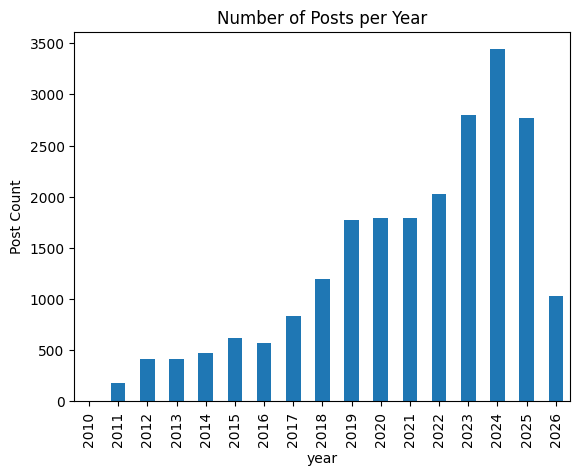

In [9]:
# parsing the created_utc column as Data time and converting the time from UTC to EST
df_filtered = df_filtered.copy()
df_filtered['created_dt'] = pd.to_datetime(df_filtered['created_utc'], unit='s', utc=True).dt.tz_convert('US/Eastern')

# creating derived columns from the created_dt column
df_filtered['year'] = df_filtered['created_dt'].dt.year
df_filtered['month'] = df_filtered['created_dt'].dt.month
df_filtered['day_of_week'] = df_filtered['created_dt'].dt.day_name()
df_filtered['hour'] = df_filtered['created_dt'].dt.hour

# plotting posts per year
plt.figure()
df_filtered.groupby('year').size().plot(kind='bar')
plt.title("Number of Posts per Year")
plt.ylabel("Post Count")
plt.show()

From the above graph, we can see that the number of posts has been steadily increasing throughout the years, with a peak in 2025. We can also see that the number of posts remained constant from 2019 - 2021. Since we are only halfway through 2026, therefore the bar for that year is shorter.

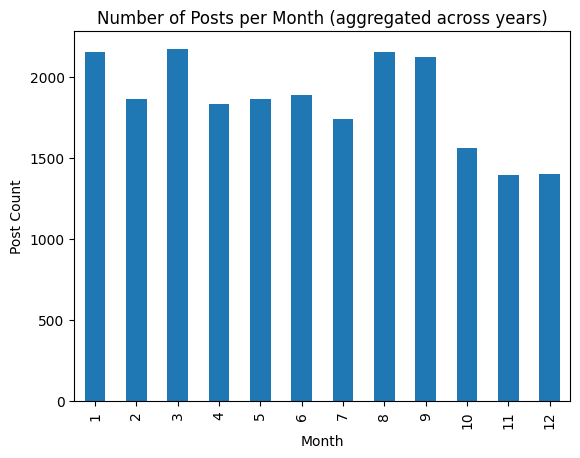

In [11]:
# plotting posts per month across all years to see seasonality
plt.figure()
df_filtered.groupby('month').size().plot(kind='bar')
plt.title("Number of Posts per Month (aggregated across years)")
plt.xlabel("Month")
plt.ylabel("Post Count")
plt.show()

From the above graph, we can see that there are peaks in January, March, August, and September. These are also times when co-op results come out. Therefore, one of our hypothesis is that students use this as a forum to discuss their co-ops.

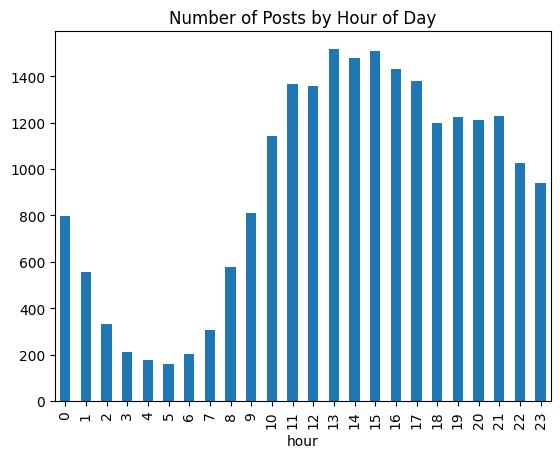

In [13]:
# plotting posts during different hours of the day
plt.figure()
df_filtered.groupby('hour').size().plot(kind='bar')
plt.title("Number of Posts by Hour of Day")
plt.show()

As would be typical for college students, most of the posts are posted after 11 am, with peaks between 1 pm - 5 pm. Also, posting activity does not go down significantly till after midnight.

We will now perform some author level EDA to see which authors are the most active on this subreddit, how many posts on average are made by a user, and how the number of unique users/authors has grown over the years.


--- Top 20 Most Active Authors ---

author
fossilfuel03            106
A-S-I0712                71
Mo0n3Y                   64
iamtheduckie             59
HealedEmu94              57
Party_Cap7331            57
OreosGotChips            54
SoySauce332              52
sprinkles_2003           48
Infinitydreamers         47
PrestigiousFig7997       45
Shockerpark              45
MochaFever               43
Zealousideal_Fan6878     42
abrahamhitler            42
Smart-Room4399           41
Blazed-Squids            39
Far-Damage3747           39
Spartacous1991           38
Onwith                   38
Name: count, dtype: int64

Number of unique authors: 8983
Number of one-time posters: 5526
Percent of posts from top 1% of authors: 12.45 %


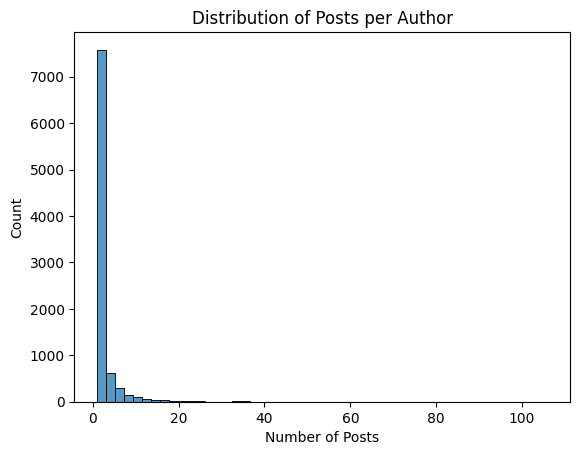

In [22]:
# identifying the top 20 authors based on number of posts
author_counts = df_filtered['author'].value_counts()
print("\n--- Top 20 Most Active Authors ---\n")
print(author_counts.head(20))

print("\nNumber of unique authors:", df_filtered['author'].nunique())
print("Number of one-time posters:", (author_counts == 1).sum())
print("Percent of posts from top 1% of authors:", round(author_counts.head(int(len(author_counts) * 0.01)).sum() / len(df_filtered) * 100, 2), "%")

plt.figure()
sns.histplot(author_counts, bins=50)
plt.title("Distribution of Posts per Author")
plt.xlabel("Number of Posts")
plt.show()

From the above results, we can see that fossilfuel03 has 106 posts on this subreddit, which makes that user the most active one. We can also see that there are 8,983 unique authors, out of which 5,526 have only made a single post. Also, we found that the top 1% of authors contribute over 12% of all the posts. This is evident in the graph where we can see that the distribution of posts per author is highly right skewed with most authors posting less than 10 posts.

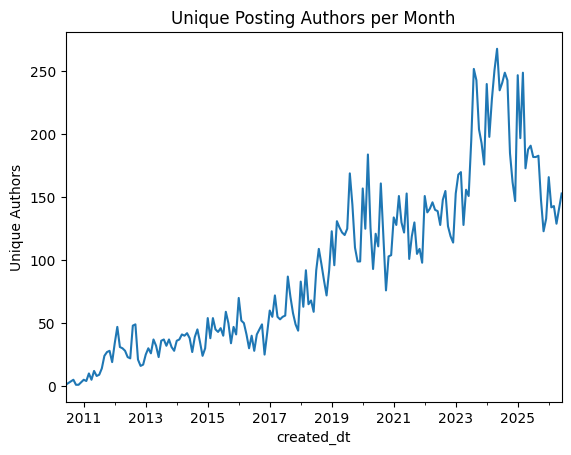

In [28]:
# plotting monthly growth in unique authors over the years
authors_over_time = df_filtered.groupby(df_filtered['created_dt'].dt.tz_localize(None).dt.to_period('M'))['author'].nunique()
plt.figure()
plt.xlabel("Year-Month")
plt.ylabel("Unique Authors")
authors_over_time.plot()
plt.title("Unique Posting Authors per Month")
plt.show()

The above graph shows that the unique authors in the the r/Drexel subreddit has been growing since 2010, with unique posting authors per month increasing from single digits to a peak of around 250-270. However, the monthly growth has not been smooth and we can see recurring seasonal dips (likely from non co-op result months, summer quarter, when fewer students are posting) and rebounds (likely from incoming students in the fall and during co-op decision months).

We will now perform some basic EDA on the actual content of these posts to find out what topics are the most frequently discussed on this subreddit.


--- Top 25 Words in Titles ---
[('coop', 1589), ('looking', 785), ('question', 593), ('campus', 588), ('student', 568), ('housing', 533), ('students', 440), ('help', 440), ('classes', 421), ('need', 394), ('program', 391), ('class', 382), ('summit', 381), ('year', 380), ('engineering', 343), ('major', 337), ('math', 328), ('online', 307), ('freshman', 286), ('take', 282), ('summer', 273), ('questions', 268), ('aid', 264), ('advice', 260), ('fall', 250)]


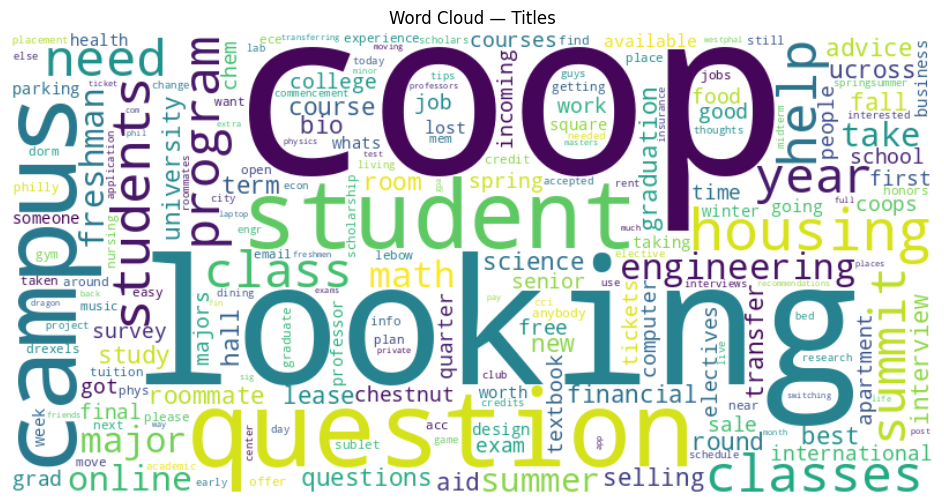

In [39]:
stop_words = set(stopwords.words('english'))
# adding Reddit and Drexel specific stopwords
stop_words.update(['drexel', 'like', 'im', 'just', 'get', 'would', 'know', 'really', 'one', 'anyone', 'dont'])

# defining a function to clean the text in the posts
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df_filtered['title_tokens'] = df_filtered['title'].apply(clean_text)
df_filtered['selftext_tokens'] = df_filtered['selftext'].apply(clean_text)

# finding the most 25 most common words in the post titles
title_word_freq = Counter([word for tokens in df_filtered['title_tokens'] for word in tokens])
print("\n--- Top 25 Words in Titles ---")
print(title_word_freq.most_common(25))

# creating a word cloud for titles
wc_title = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(title_word_freq)
plt.figure(figsize=(12, 6))
plt.imshow(wc_title, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Titles")
plt.show()


--- Top 25 Words in Selftext ---
[('coop', 4074), ('year', 3414), ('class', 3207), ('looking', 3128), ('also', 3039), ('want', 3007), ('take', 2987), ('student', 2606), ('time', 2602), ('thanks', 2543), ('students', 2535), ('need', 2512), ('got', 2495), ('classes', 2469), ('ive', 2417), ('people', 2320), ('campus', 2247), ('wondering', 2195), ('program', 2184), ('major', 2183), ('please', 2036), ('going', 1988), ('good', 1980), ('help', 1970), ('school', 1940)]


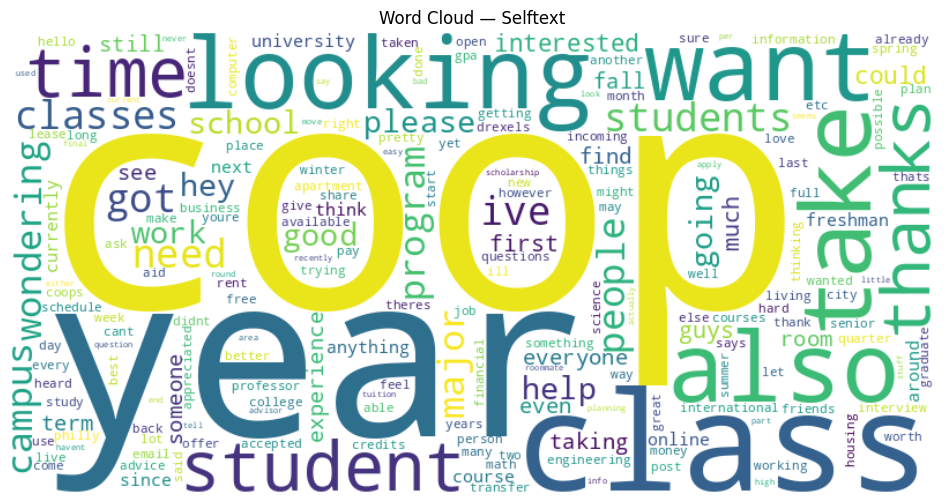

In [40]:
# finding the most common words in the text of the posts
selftext_word_freq = Counter([word for tokens in df_filtered['selftext_tokens'] for word in tokens])
print("\n--- Top 25 Words in Selftext ---")
print(selftext_word_freq.most_common(25))

# creating a word cloud for the text
wc_selftext = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(selftext_word_freq)
plt.figure(figsize=(12, 6))
plt.imshow(wc_selftext, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Selftext")
plt.show()

From the above results and word clouds, we can clearly see that our initial hypothesis of students using this subreddit to talk about **Coop** was true as it is the most dominant word in both the titles and the text of the posts. The other words are centered around academics (classes, class, program, major), campus life (campus, housing, summit), and seeking help (looking, questions, help, need, advice).